In [1]:
# Signal Processing Pipeline
# Neonatal Apnea Monitor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch

# Sampling frequency
FS = 100

print("Libraries imported successfully.")
print("Sampling frequency:", FS, "Hz")

Libraries imported successfully.
Sampling frequency: 100 Hz


In [2]:
# Load Apnea-ECG record and annotations

record = wfdb.rdrecord(
    'a01',
    pn_dir='apnea-ecg'
)

annotation = wfdb.rdann(
    'a01',
    'apn',
    pn_dir='apnea-ecg'
)

# Extract ECG signal
ecg = record.p_signal[:, 0]

# Extract annotation times
annotation_times = annotation.sample / record.fs

# Separate apnea and normal annotations
apnea_times = annotation_times[
    np.array(annotation.symbol) == 'A'
]

normal_times = annotation_times[
    np.array(annotation.symbol) == 'N'
]

print("ECG loaded successfully.")
print("ECG samples:", len(ecg))
print("Sampling frequency:", record.fs, "Hz")
print("ECG duration:", len(ecg) / record.fs / 60, "minutes")
print("Apnea annotations:", len(apnea_times))
print("Normal annotations:", len(normal_times))

ECG loaded successfully.
ECG samples: 2957000
Sampling frequency: 100 Hz
ECG duration: 492.8333333333333 minutes
Apnea annotations: 470
Normal annotations: 19


In [3]:
# Inspect raw ECG signal

print("First 10 ECG samples:")
print(ecg[:10])

print("\nECG statistics:")
print("Minimum:", np.min(ecg))
print("Maximum:", np.max(ecg))
print("Mean:", np.mean(ecg))
print("Standard deviation:", np.std(ecg))

First 10 ECG samples:
[-0.06  -0.065 -0.06  -0.075 -0.065 -0.07  -0.07  -0.09  -0.08  -0.095]

ECG statistics:
Minimum: -1.655
Maximum: 2.44
Mean: 0.0005639279675346633
Standard deviation: 0.24446405945045407


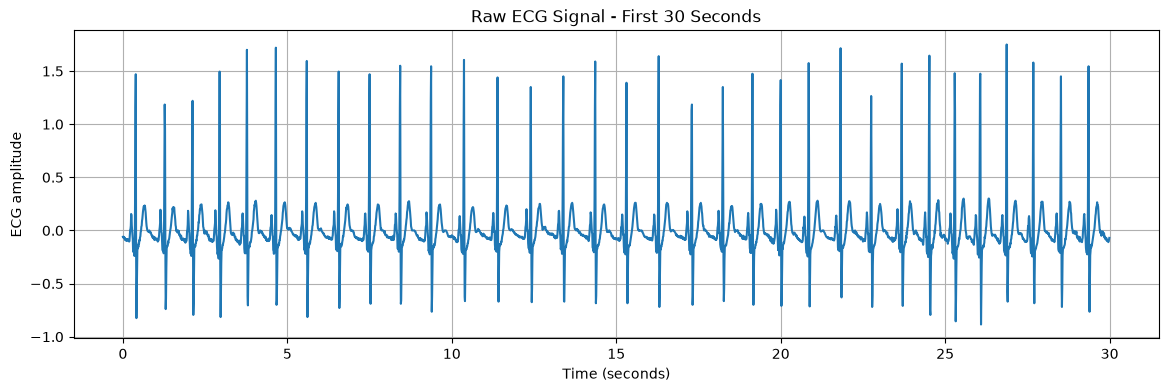

In [4]:
# Plot first 30 seconds of raw ECG

duration = 30  # seconds
samples = int(duration * record.fs)

time = np.arange(samples) / record.fs

plt.figure(figsize=(14, 4))
plt.plot(time, ecg[:samples])
plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("Raw ECG Signal - First 30 Seconds")
plt.grid(True)
plt.show()

In [5]:
# Design ECG bandpass filter
# Passband: 0.5 Hz to 40 Hz

LOWCUT = 0.5
HIGHCUT = 40.0
FILTER_ORDER = 4

nyquist = 0.5 * record.fs

low = LOWCUT / nyquist
high = HIGHCUT / nyquist

b_band, a_band = butter(
    FILTER_ORDER,
    [low, high],
    btype='band'
)

print("Bandpass filter designed successfully.")
print("Low cutoff:", LOWCUT, "Hz")
print("High cutoff:", HIGHCUT, "Hz")
print("Filter order:", FILTER_ORDER)

Bandpass filter designed successfully.
Low cutoff: 0.5 Hz
High cutoff: 40.0 Hz
Filter order: 4


In [6]:
# Apply bandpass filter to ECG

ecg_bandpass = filtfilt(
    b_band,
    a_band,
    ecg
)

print("Bandpass filtering completed.")
print("Filtered ECG samples:", len(ecg_bandpass))
print("Filtered minimum:", np.min(ecg_bandpass))
print("Filtered maximum:", np.max(ecg_bandpass))
print("Filtered mean:", np.mean(ecg_bandpass))
print("Filtered standard deviation:", np.std(ecg_bandpass))

Bandpass filtering completed.
Filtered ECG samples: 2957000
Filtered minimum: -1.7337207359124198
Filtered maximum: 2.239101532719322
Filtered mean: 2.9158421837490847e-08
Filtered standard deviation: 0.2430486966792874


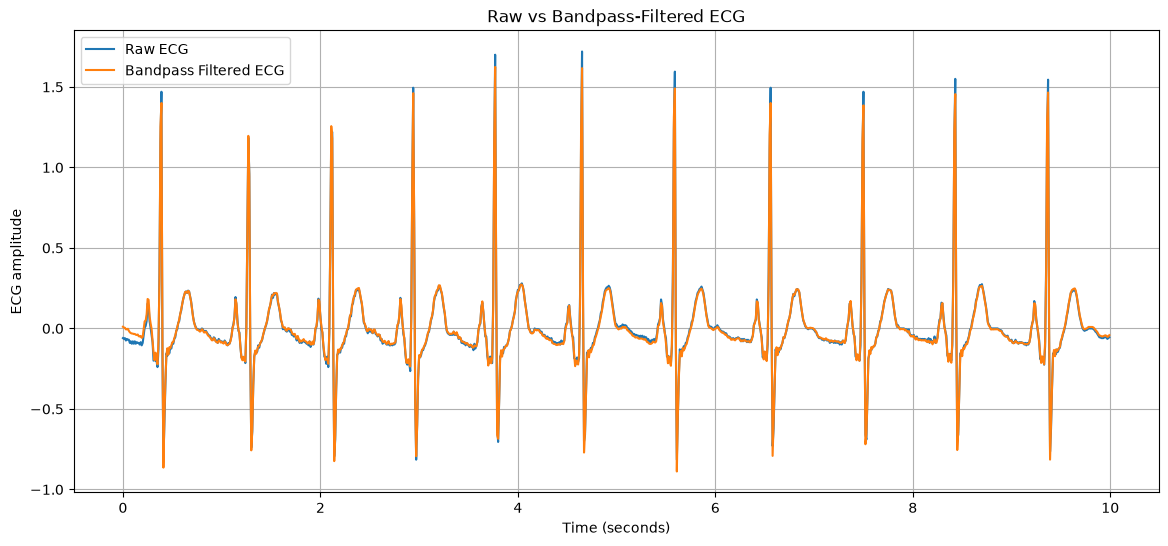

In [7]:
# Compare raw ECG and bandpass-filtered ECG

duration = 10  # seconds
samples = int(duration * record.fs)

time = np.arange(samples) / record.fs

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    ecg[:samples],
    label="Raw ECG"
)

plt.plot(
    time,
    ecg_bandpass[:samples],
    label="Bandpass Filtered ECG"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("Raw vs Bandpass-Filtered ECG")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Design 50 Hz notch filter

NOTCH_FREQ = 50.0
QUALITY_FACTOR = 30.0

b_notch, a_notch = iirnotch(
    NOTCH_FREQ,
    QUALITY_FACTOR,
    record.fs
)

print("Notch filter designed successfully.")
print("Notch frequency:", NOTCH_FREQ, "Hz")
print("Quality factor:", QUALITY_FACTOR)

Notch filter designed successfully.
Notch frequency: 50.0 Hz
Quality factor: 30.0


In [9]:
# Apply 50 Hz notch filter

ecg_filtered = filtfilt(
    b_notch,
    a_notch,
    ecg_bandpass
)

print("Notch filtering completed.")
print("Final filtered ECG samples:", len(ecg_filtered))
print("Final mean:", np.mean(ecg_filtered))
print("Final standard deviation:", np.std(ecg_filtered))

Notch filtering completed.
Final filtered ECG samples: 2957000
Final mean: 2.9158984540097034e-08
Final standard deviation: 0.2428719605544175


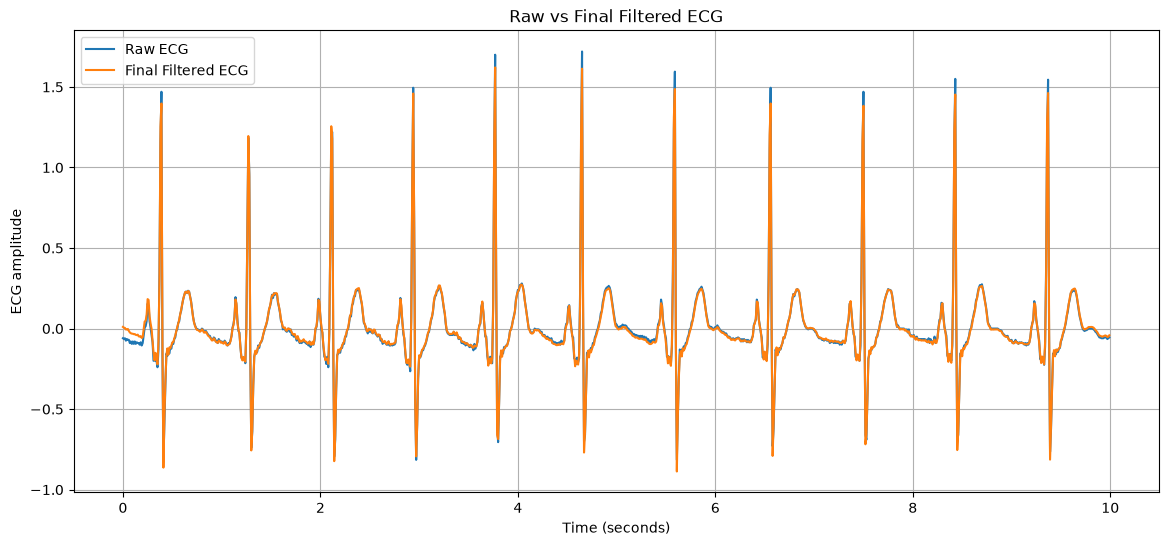

In [10]:
# Compare raw ECG with final filtered ECG

duration = 10
samples = int(duration * record.fs)

time = np.arange(samples) / record.fs

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    ecg[:samples],
    label="Raw ECG"
)

plt.plot(
    time,
    ecg_filtered[:samples],
    label="Final Filtered ECG"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("Raw vs Final Filtered ECG")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Detect R-peaks from filtered ECG

min_distance = int(0.4 * record.fs)

peaks, properties = find_peaks(
    ecg_filtered,
    distance=min_distance,
    prominence=0.5
)

print("R-peak detection completed.")
print("Number of R-peaks detected:", len(peaks))
print("First 10 R-peak sample positions:")
print(peaks[:10])

print("First 10 R-peak times (seconds):")
print(peaks[:10] / record.fs)

R-peak detection completed.
Number of R-peaks detected: 29941
First 10 R-peak sample positions:
[ 39 127 211 294 377 465 559 656 750 843]
First 10 R-peak times (seconds):
[0.39 1.27 2.11 2.94 3.77 4.65 5.59 6.56 7.5  8.43]


In [12]:
# Calculate RR intervals

rr_intervals = np.diff(peaks) / record.fs

print("RR interval calculation completed.")
print("Number of RR intervals:", len(rr_intervals))

print("\nFirst 10 RR intervals (seconds):")
print(rr_intervals[:10])

print("\nRR statistics:")
print("Mean RR:", np.mean(rr_intervals), "seconds")
print("Minimum RR:", np.min(rr_intervals), "seconds")
print("Maximum RR:", np.max(rr_intervals), "seconds")
print("Standard deviation:", np.std(rr_intervals), "seconds")

RR interval calculation completed.
Number of RR intervals: 29940

First 10 RR intervals (seconds):
[0.88 0.84 0.83 0.83 0.88 0.94 0.97 0.94 0.93 0.94]

RR statistics:
Mean RR: 0.987444889779559 seconds
Minimum RR: 0.41 seconds
Maximum RR: 1.71 seconds
Standard deviation: 0.15929880734743698 seconds


In [13]:
# Calculate instantaneous heart rate from RR intervals

heart_rate = 60 / rr_intervals

print("Heart rate calculation completed.")

print("\nFirst 10 heart-rate values (BPM):")
print(heart_rate[:10])

print("\nHeart rate statistics:")
print("Mean HR:", np.mean(heart_rate), "BPM")
print("Minimum HR:", np.min(heart_rate), "BPM")
print("Maximum HR:", np.max(heart_rate), "BPM")
print("Standard deviation:", np.std(heart_rate), "BPM")

Heart rate calculation completed.

First 10 heart-rate values (BPM):
[68.18181818 71.42857143 72.28915663 72.28915663 68.18181818 63.82978723
 61.8556701  63.82978723 64.51612903 63.82978723]

Heart rate statistics:
Mean HR: 62.455946774519504 BPM
Minimum HR: 35.08771929824562 BPM
Maximum HR: 146.34146341463415 BPM
Standard deviation: 10.744590021174501 BPM


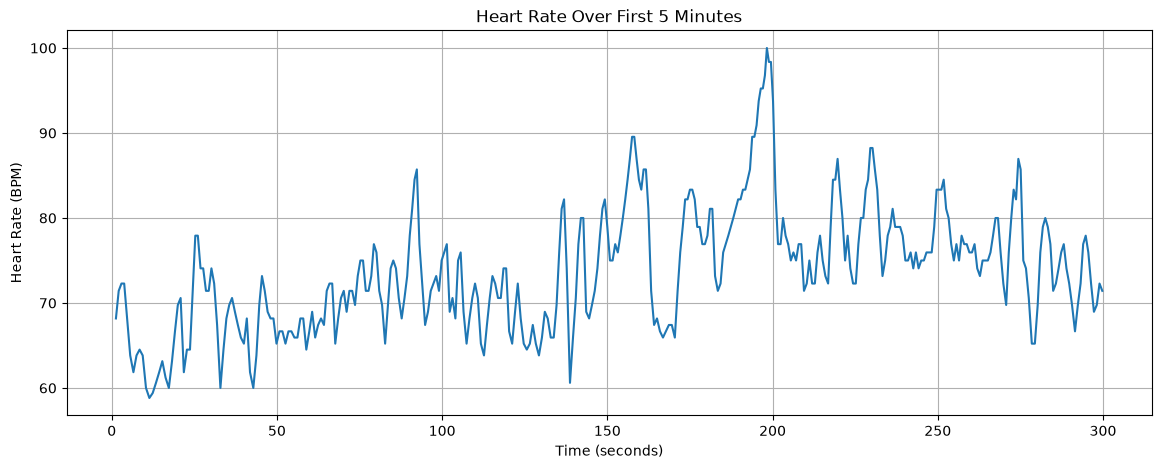

In [14]:
# Plot heart rate over the first 5 minutes

hr_duration = 5 * 60  # 5 minutes

# RR intervals correspond to the time of the second R-peak onward
rr_times = peaks[1:] / record.fs

# Select HR values within first 5 minutes
mask = rr_times <= hr_duration

plt.figure(figsize=(14, 5))

plt.plot(
    rr_times[mask],
    heart_rate[mask]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Over First 5 Minutes")
plt.grid(True)
plt.show()

In [15]:
# Calculate SDNN

sdnn = np.std(rr_intervals, ddof=1)

print("SDNN calculation completed.")
print("SDNN:", sdnn, "seconds")
print("SDNN:", sdnn * 1000, "milliseconds")

SDNN calculation completed.
SDNN: 0.15930146771480355 seconds
SDNN: 159.30146771480355 milliseconds


In [17]:
# Calculate RMSSD

rr_differences = np.diff(rr_intervals)

rmssd = np.sqrt(
    np.mean(rr_differences ** 2)
)

print("RMSSD calculation completed.")
print("RMSSD:", rmssd, "seconds")
print("RMSSD:", rmssd * 1000, "milliseconds")

RMSSD calculation completed.
RMSSD: 0.07719107595108726 seconds
RMSSD: 77.19107595108726 milliseconds


In [18]:
# Summary of time-domain HRV features

print("Time-Domain HRV Summary")
print("-----------------------")
print(f"SDNN  : {sdnn * 1000:.2f} ms")
print(f"RMSSD : {rmssd * 1000:.2f} ms")

Time-Domain HRV Summary
-----------------------
SDNN  : 159.30 ms
RMSSD : 77.19 ms


In [19]:
# Prepare RR intervals for frequency-domain HRV

rr_times = peaks[1:] / record.fs

# Remove any invalid RR values
valid = np.isfinite(rr_intervals) & (rr_intervals > 0)

rr_times_valid = rr_times[valid]
rr_valid = rr_intervals[valid]

# Uniform sampling frequency for HRV analysis
HRV_FS = 4.0  # Hz

uniform_times = np.arange(
    rr_times_valid[0],
    rr_times_valid[-1],
    1 / HRV_FS
)

# Interpolate RR intervals onto uniform time grid
rr_interp = np.interp(
    uniform_times,
    rr_times_valid,
    rr_valid
)

print("RR interpolation completed.")
print("Original RR intervals:", len(rr_intervals))
print("Valid RR intervals:", len(rr_valid))
print("Interpolated samples:", len(rr_interp))
print("HRV sampling frequency:", HRV_FS, "Hz")

RR interpolation completed.
Original RR intervals: 29940
Valid RR intervals: 29940
Interpolated samples: 118253
HRV sampling frequency: 4.0 Hz


In [20]:
# Calculate power spectral density using Welch's method

frequencies, psd = welch(
    rr_interp,
    fs=HRV_FS,
    nperseg=1024
)

print("Welch PSD calculation completed.")
print("Number of frequency bins:", len(frequencies))
print("Frequency range:", frequencies[0], "to", frequencies[-1], "Hz")

Welch PSD calculation completed.
Number of frequency bins: 513
Frequency range: 0.0 to 2.0 Hz


In [21]:
# Calculate LF and HF power

LF_LOW = 0.04
LF_HIGH = 0.15

HF_LOW = 0.15
HF_HIGH = 0.40

# Select frequency bands
lf_mask = (frequencies >= LF_LOW) & (frequencies < LF_HIGH)
hf_mask = (frequencies >= HF_LOW) & (frequencies <= HF_HIGH)

# Calculate power using numerical integration
lf_power = np.trapezoid(
    psd[lf_mask],
    frequencies[lf_mask]
)

hf_power = np.trapezoid(
    psd[hf_mask],
    frequencies[hf_mask]
)

print("Frequency-domain HRV calculation completed.")
print(f"LF power: {lf_power:.6f}")
print(f"HF power: {hf_power:.6f}")

Frequency-domain HRV calculation completed.
LF power: 0.005110
HF power: 0.001015


In [22]:
# Calculate LF/HF ratio

lf_hf_ratio = lf_power / hf_power

print("LF/HF calculation completed.")
print(f"LF power : {lf_power:.6f}")
print(f"HF power : {hf_power:.6f}")
print(f"LF/HF ratio: {lf_hf_ratio:.3f}")

LF/HF calculation completed.
LF power : 0.005110
HF power : 0.001015
LF/HF ratio: 5.032


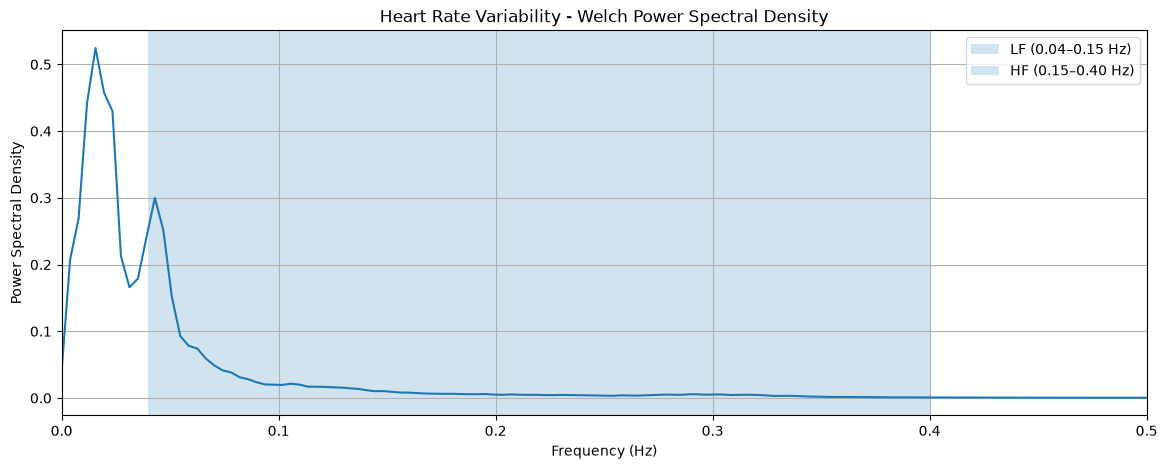

In [23]:
# Plot Welch Power Spectral Density

plt.figure(figsize=(14, 5))

plt.plot(
    frequencies,
    psd
)

# Highlight LF and HF regions
plt.axvspan(
    LF_LOW,
    LF_HIGH,
    alpha=0.2,
    label="LF (0.04–0.15 Hz)"
)

plt.axvspan(
    HF_LOW,
    HF_HIGH,
    alpha=0.2,
    label="HF (0.15–0.40 Hz)"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Heart Rate Variability - Welch Power Spectral Density")
plt.xlim(0, 0.5)
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Create 30-second analysis segments

SEGMENT_DURATION = 30  # seconds
SEGMENT_SAMPLES = int(SEGMENT_DURATION * record.fs)

segment_starts = np.arange(
    0,
    len(ecg_filtered) - SEGMENT_SAMPLES + 1,
    SEGMENT_SAMPLES
)

print("Segment creation completed.")
print("Segment duration:", SEGMENT_DURATION, "seconds")
print("Number of segments:", len(segment_starts))

Segment creation completed.
Segment duration: 30 seconds
Number of segments: 985


In [25]:
# Assign apnea/normal labels to each 30-second segment

segment_labels = []

for start_sample in segment_starts:

    start_time = start_sample / record.fs
    end_time = start_time + SEGMENT_DURATION

    # Check whether an apnea annotation occurs inside this segment
    apnea_in_segment = np.any(
        (apnea_times >= start_time) &
        (apnea_times < end_time)
    )

    if apnea_in_segment:
        segment_labels.append(1)
    else:
        segment_labels.append(0)

segment_labels = np.array(segment_labels)

print("Segment labeling completed.")
print("Total segments:", len(segment_labels))
print("Normal segments:", np.sum(segment_labels == 0))
print("Apnea segments:", np.sum(segment_labels == 1))

Segment labeling completed.
Total segments: 985
Normal segments: 515
Apnea segments: 470


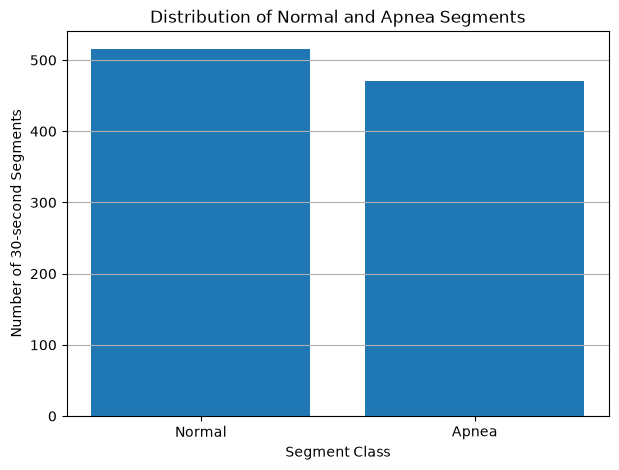

In [26]:
# Visualize segment label distribution

labels = ["Normal", "Apnea"]
counts = [
    np.sum(segment_labels == 0),
    np.sum(segment_labels == 1)
]

plt.figure(figsize=(7, 5))

plt.bar(labels, counts)

plt.xlabel("Segment Class")
plt.ylabel("Number of 30-second Segments")
plt.title("Distribution of Normal and Apnea Segments")
plt.grid(axis="y")

plt.show()

In [27]:
# Extract HR and HRV features for each 30-second segment

segment_features = []

for start_sample in segment_starts:

    end_sample = start_sample + SEGMENT_SAMPLES
    segment_ecg = ecg_filtered[start_sample:end_sample]

    # Detect R-peaks within the segment
    segment_peaks, _ = find_peaks(
        segment_ecg,
        distance=int(0.4 * record.fs),
        prominence=0.5
    )

    # Need at least 3 peaks to calculate meaningful RR features
    if len(segment_peaks) < 3:
        segment_features.append([
            np.nan, np.nan, np.nan, np.nan
        ])
        continue

    # RR intervals
    segment_rr = np.diff(segment_peaks) / record.fs

    # Heart rate
    segment_hr = 60 / segment_rr

    # SDNN
    segment_sdnn = np.std(segment_rr, ddof=1)

    # RMSSD
    segment_rmssd = np.sqrt(
        np.mean(np.diff(segment_rr) ** 2)
    )

    segment_features.append([
        np.mean(segment_hr),
        np.std(segment_hr),
        segment_sdnn,
        segment_rmssd
    ])

segment_features = np.array(segment_features)

print("Segment feature extraction completed.")
print("Feature matrix shape:", segment_features.shape)
print("Features: Mean HR, HR Std, SDNN, RMSSD")

Segment feature extraction completed.
Feature matrix shape: (985, 4)
Features: Mean HR, HR Std, SDNN, RMSSD


In [28]:
# Create a DataFrame containing segment-level features and labels

feature_df = pd.DataFrame(
    segment_features,
    columns=[
        "mean_hr",
        "std_hr",
        "sdnn",
        "rmssd"
    ]
)

feature_df["label"] = segment_labels

print("Feature DataFrame created.")
print("Shape:", feature_df.shape)

print("\nFirst 5 rows:")
print(feature_df.head())

Feature DataFrame created.
Shape: (985, 5)

First 5 rows:
     mean_hr    std_hr      sdnn     rmssd  label
0  66.707858  5.443214  0.073264  0.041968      0
1  66.980921  2.967753  0.041309  0.041721      0
2  71.055571  2.952498  0.036023  0.034333      0
3  72.269609  4.792736  0.053637  0.041195      0
4  70.933670  6.024589  0.070774  0.054356      0


In [29]:
# Compare physiological features between Normal and Apnea segments

comparison = feature_df.groupby("label")[
    ["mean_hr", "std_hr", "sdnn", "rmssd"]
].mean()

comparison.index = ["Normal", "Apnea"]

print("Mean feature values by class:")
print(comparison)

Mean feature values by class:
          mean_hr    std_hr      sdnn     rmssd
Normal  62.165994  7.528933  0.114553  0.071582
Apnea   61.558046  8.005285  0.123095  0.076622


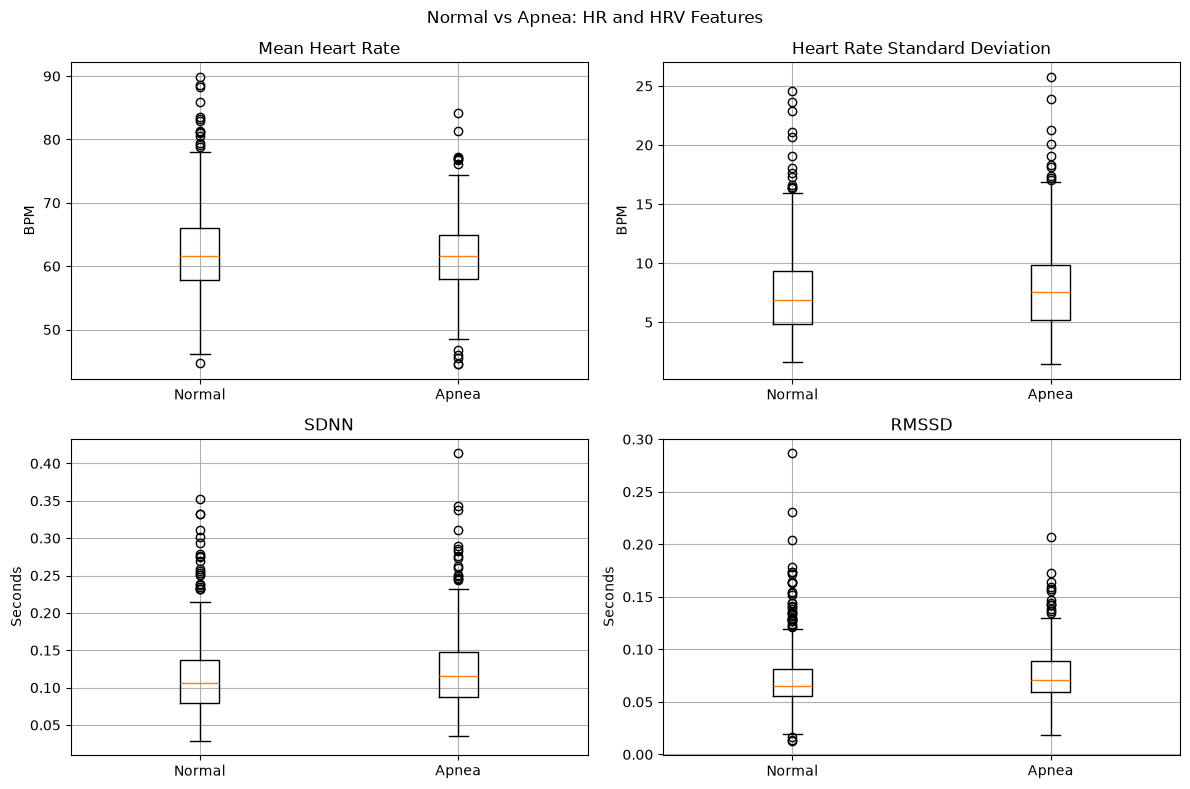

In [31]:
# Compare HR and HRV feature distributions

normal_data = feature_df[feature_df["label"] == 0]
apnea_data = feature_df[feature_df["label"] == 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Mean HR
axes[0, 0].boxplot(
    [normal_data["mean_hr"].dropna(),
     apnea_data["mean_hr"].dropna()],
    tick_labels=["Normal", "Apnea"]
)
axes[0, 0].set_title("Mean Heart Rate")
axes[0, 0].set_ylabel("BPM")
axes[0, 0].grid(True)

# HR standard deviation
axes[0, 1].boxplot(
    [normal_data["std_hr"].dropna(),
     apnea_data["std_hr"].dropna()],
    tick_labels=["Normal", "Apnea"]
)
axes[0, 1].set_title("Heart Rate Standard Deviation")
axes[0, 1].set_ylabel("BPM")
axes[0, 1].grid(True)

# SDNN
axes[1, 0].boxplot(
    [normal_data["sdnn"].dropna(),
     apnea_data["sdnn"].dropna()],
    tick_labels=["Normal", "Apnea"]
)
axes[1, 0].set_title("SDNN")
axes[1, 0].set_ylabel("Seconds")
axes[1, 0].grid(True)

# RMSSD
axes[1, 1].boxplot(
    [normal_data["rmssd"].dropna(),
     apnea_data["rmssd"].dropna()],
    tick_labels=["Normal", "Apnea"]
)
axes[1, 1].set_title("RMSSD")
axes[1, 1].set_ylabel("Seconds")
axes[1, 1].grid(True)

plt.suptitle("Normal vs Apnea: HR and HRV Features")
plt.tight_layout()
plt.show()

In [32]:
# Statistical comparison between Normal and Apnea segments

from scipy.stats import mannwhitneyu

features_to_test = [
    "mean_hr",
    "std_hr",
    "sdnn",
    "rmssd"
]

print("Mann-Whitney U Test Results")
print("=" * 40)

for feature in features_to_test:

    normal_values = normal_data[feature].dropna()
    apnea_values = apnea_data[feature].dropna()

    statistic, p_value = mannwhitneyu(
        normal_values,
        apnea_values,
        alternative="two-sided"
    )

    print(f"\n{feature}")
    print(f"U statistic: {statistic:.2f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print("Result: Statistically significant")
    else:
        print("Result: Not statistically significant")

Mann-Whitney U Test Results

mean_hr
U statistic: 124320.00
p-value: 0.460067
Result: Not statistically significant

std_hr
U statistic: 110384.00
p-value: 0.017035
Result: Statistically significant

sdnn
U statistic: 106935.00
p-value: 0.001581
Result: Statistically significant

rmssd
U statistic: 101124.50
p-value: 0.000008
Result: Statistically significant


In [33]:
# Inspect available signal channels in the record

print("Number of signal channels:", record.n_sig)
print("Signal names:", record.sig_name)
print("Signal units:", record.units)

Number of signal channels: 1
Signal names: ['ECG']
Signal units: ['mV']


In [34]:
# Signal processing pipeline summary

print("=" * 55)
print("NEONATAL APNEA ECG SIGNAL PROCESSING SUMMARY")
print("=" * 55)

print("\nSignal:")
print(f"  Sampling frequency : {record.fs} Hz")
print(f"  ECG samples        : {len(ecg)}")
print(f"  Duration           : {len(ecg) / record.fs / 60:.2f} minutes")

print("\nFiltering:")
print("  Bandpass           : 0.5 - 40 Hz")
print("  Notch              : 50 Hz")
print("  Filter order       : 4")

print("\nR-peak / HR:")
print(f"  R-peaks detected   : {len(peaks)}")
print(f"  Mean HR            : {np.mean(heart_rate):.2f} BPM")

print("\nHRV:")
print(f"  SDNN               : {sdnn * 1000:.2f} ms")
print(f"  RMSSD              : {rmssd * 1000:.2f} ms")
print(f"  LF power           : {lf_power:.6f}")
print(f"  HF power           : {hf_power:.6f}")
print(f"  LF/HF ratio        : {lf_hf_ratio:.3f}")

print("\nSegment analysis:")
print(f"  Segment duration   : {SEGMENT_DURATION} seconds")
print(f"  Total segments     : {len(feature_df)}")
print(f"  Normal segments    : {np.sum(segment_labels == 0)}")
print(f"  Apnea segments     : {np.sum(segment_labels == 1)}")

print("\nStatistically significant features (p < 0.05):")
print("  HR standard deviation")
print("  SDNN")
print("  RMSSD")

print("\nRespiration:")
print("  Not available in Apnea-ECG a01 (ECG-only record)")

print("=" * 55)

NEONATAL APNEA ECG SIGNAL PROCESSING SUMMARY

Signal:
  Sampling frequency : 100 Hz
  ECG samples        : 2957000
  Duration           : 492.83 minutes

Filtering:
  Bandpass           : 0.5 - 40 Hz
  Notch              : 50 Hz
  Filter order       : 4

R-peak / HR:
  R-peaks detected   : 29941
  Mean HR            : 62.46 BPM

HRV:
  SDNN               : 159.30 ms
  RMSSD              : 77.19 ms
  LF power           : 0.005110
  HF power           : 0.001015
  LF/HF ratio        : 5.032

Segment analysis:
  Segment duration   : 30 seconds
  Total segments     : 985
  Normal segments    : 515
  Apnea segments     : 470

Statistically significant features (p < 0.05):
  HR standard deviation
  SDNN
  RMSSD

Respiration:
  Not available in Apnea-ECG a01 (ECG-only record)
